In [1]:
from mlwpy import *
%matplotlib inline

In [2]:
iris = datasets.load_iris()

tts = skms.train_test_split(iris.data,iris.target,test_size = .33, random_state = 21)

(iris_train_ftrs,iris_test_ftrs,iris_train_tgt,iris_test_tgt) = tts

#### Baseline Classifiers

In [3]:
baseline = dummy.DummyClassifier(strategy = "most_frequent")
baseline.fit(iris_train_ftrs,iris_train_tgt)
baseline_preds = baseline.predict(iris_test_ftrs)
baseline_acc = metrics.accuracy_score(baseline_preds, iris_test_tgt)
print(baseline_acc)

0.3


In [4]:
strategies = ['constant','uniform','stratified','prior','most_frequent']

#set up args to create different DummyClassifier strategies
baseline_args = [{'strategy':s} for s in strategies]
baseline_args[0]['constant'] = 0 #class 0 is setosa

accuracies = []
for bla in baseline_args:
    baseline = dummy.DummyClassifier(**bla)
    baseline.fit(iris_train_ftrs,iris_train_tgt)
    baseline_preds = baseline.predict(iris_test_ftrs)
    accuracies.append(metrics.accuracy_score(baseline_preds,iris_test_tgt))

df = pd.DataFrame({'accuracy':accuracies}, index = strategies)
df

,accuracy
constant,0.3600
uniform,0.3800
stratified,0.3400
prior,0.3000
most_frequent,0.3000


#### Metrics for Classification

In [5]:

# helpful stdlib tool for cleaning up printouts
import textwrap
print(textwrap.fill(str(sorted(metrics.get_scorer_names())), 
                    width=70))

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score',
'average_precision', 'balanced_accuracy', 'completeness_score',
'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples',
'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score',
'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples',
'jaccard_weighted', 'matthews_corrcoef', 'max_error',
'mutual_info_score', 'neg_brier_score', 'neg_log_loss',
'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error',
'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance',
'neg_mean_squared_error', 'neg_mean_squared_log_error',
'neg_median_absolute_error', 'neg_negative_likelihood_ratio',
'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error',
'normalized_mutual_info_score', 'positive_likelihood_ratio',
'precision', 'precision_macro', 'precision_micro',
'precision_samples', 'precision_weighted', 'r2', 'rand_score',
'recall', 'recall_macro', 'recall_micro', 'recall_samples',
'recall_weighted', 'roc_auc',

In [6]:
knn = neighbors.KNeighborsClassifier()

# help(knn.score) # verbose, but complete

print(knn.score.__doc__.splitlines()[0])
print('\n---and---\n')
print("\n".join(knn.score.__doc__.splitlines()[-6:]))



---and---


        Returns
        -------
        score : float
            Mean accuracy of ``self.predict(X)`` w.r.t. `y`.
        


#### Confusion Matrix

In [7]:
tgt_preds = (neighbors.KNeighborsClassifier()
                      .fit(iris_train_ftrs, iris_train_tgt)
                      .predict(iris_test_ftrs))

accuracy  = metrics.accuracy_score(tgt_preds, iris_test_tgt)
print("accuracy",accuracy)
cm = metrics.confusion_matrix(tgt_preds, iris_test_tgt)
print("confusion matrix:", cm, sep="\n")


accuracy 0.94
confusion matrix:
[[18  0  0]
 [ 0 16  2]
 [ 0  1 13]]


Text(20.72222222222222, 0.5, 'Actual')

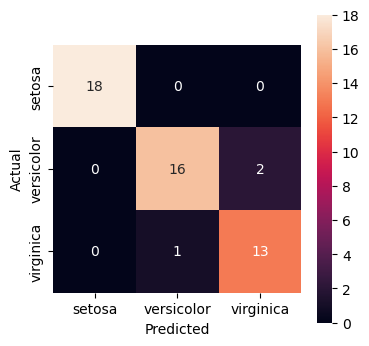

In [8]:
ax,fig = plt.subplots(1,1,figsize=(4,4))
ax = sns.heatmap(cm, annot= True, square = True,
                xticklabels = iris.target_names,
                yticklabels = iris.target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

In [9]:
macro_prec = metrics.precision_score(iris_test_tgt,tgt_preds, average = 'macro')

print("macro:",macro_prec)

cm = metrics.confusion_matrix(iris_test_tgt,tgt_preds)
n_labels = len(iris.target_names)
print(
    "should be equal macroaverage:",
    (np.diag(cm)/cm.sum(axis=0)).sum() / n_labels
)

macro: 0.9391534391534391
should be equal macroaverage: 0.9391534391534391


In [10]:
micro_prec = metrics.precision_score(iris_test_tgt,tgt_preds, average = 'micro')

print('micro:',micro_prec)

cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
print("should be equal microaverage:",
     (np.diag(cm).sum())/cm.sum())

micro: 0.94
should be equal microaverage: 0.94


In [11]:
print(metrics.classification_report(iris_test_tgt, tgt_preds))

#verify sum-across rows
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
print("row counts equal support:",cm.sum(axis=1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.89      0.94      0.91        17
           2       0.93      0.87      0.90        15

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50

row counts equal support: [18 17 15]


In [12]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data,columns = iris.feature_names)
iris_df['target'] = iris.target
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1000,3.5000,1.4000,0.2000,0
1,4.9000,3.0000,1.4000,0.2000,0
2,4.7000,3.2000,1.3000,0.2000,0
3,4.6000,3.1000,1.5000,0.2000,0
4,5.0000,3.6000,1.4000,0.2000,0
...,...,...,...,...,...
145,6.7000,3.0000,5.2000,2.3000,2
146,6.3000,2.5000,5.0000,1.9000,2
147,6.5000,3.0000,5.2000,2.0000,2
148,6.2000,3.4000,5.4000,2.3000,2


#### Binary ROC

In [13]:
is_versicolor = iris.target == 1

tts_1c = skms.train_test_split(iris.data,is_versicolor,test_size = .33, random_state = 21)
(iris_1c_train_ftrs,iris_1c_test_ftrs,iris_1c_train_tgt, iris_1c_test_tgt) = tts_1c

#build, fit , predict(probability scores)
gnb = naive_bayes.GaussianNB()
prob_true = (gnb.fit(iris_1c_train_ftrs,iris_1c_train_tgt).predict_proba(iris_1c_test_ftrs)[:,1])
prob_true

array([0.9799, 0.    , 0.    , 0.    , 0.9527, 0.9277, 0.    , 0.0091,
       0.    , 0.    , 0.8564, 0.9588, 0.    , 0.    , 0.    , 0.2639,
       0.2358, 0.961 , 0.    , 0.05  , 0.319 , 0.8894, 0.7879, 0.9656,
       0.    , 0.3937, 0.    , 0.    , 0.9795, 0.    , 0.    , 0.    ,
       0.1061, 0.    , 0.348 , 0.9374, 0.3949, 0.    , 0.    , 0.05  ,
       0.116 , 0.    , 0.0102, 0.9713, 0.    , 0.    , 0.    , 0.    ,
       0.9582, 0.    ])

FPR: [0.     0.     0.     0.0606 0.0606 0.1212 0.1212 0.1818 1.    ] TPR: [0.     0.0588 0.8824 0.8824 0.9412 0.9412 1.     1.     1.    ]


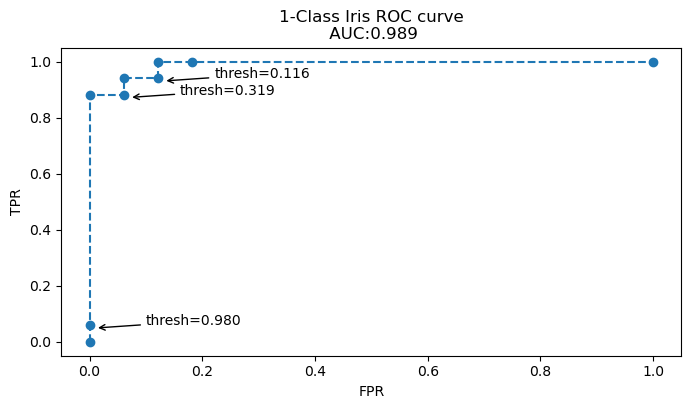

In [14]:
fpr, tpr , thresh = metrics.roc_curve(iris_1c_test_tgt, prob_true)

auc = metrics.auc(fpr,tpr)

print("FPR: {}".format(fpr),
     "TPR: {}".format(tpr))

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(fpr,tpr,'o--')
ax.set_title('1-Class Iris ROC curve\n AUC:{:.3f}'.format(auc))
ax.set_ylabel("TPR")
ax.set_xlabel("FPR")

#do a bit of work to label some points with their respective thresholds
investigate = np.array([1,3,5])
for idx in investigate:
    th, f,t = thresh[idx],fpr[idx],tpr[idx]
    ax.annotate('thresh={:.3f}'.format(th),xy=(f+.01,t-.01),xytext=(f+.1,t),arrowprops = {'arrowstyle':'->'})

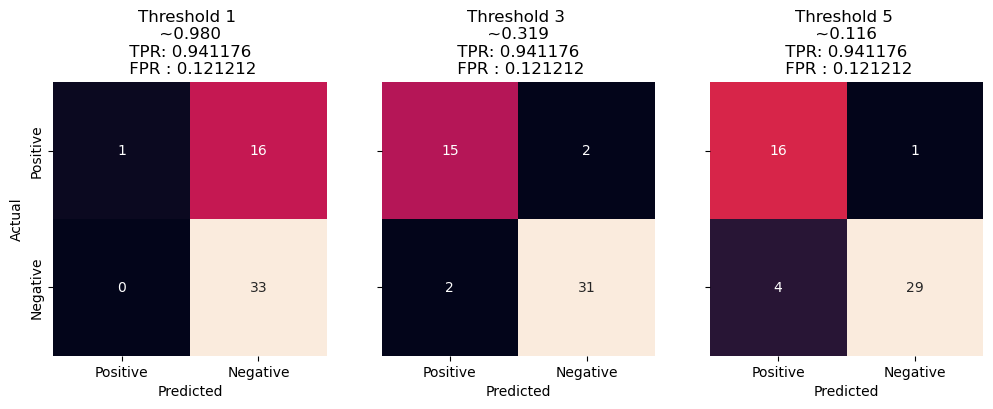

In [15]:
title_fmt = "Threshold {} \n ~{:5.3f} \n TPR: {:3f} \n FPR : {:3f}"
pn=['Positive','Negative']

add_args = {
    'xticklabels':pn,
    'yticklabels':pn,
    'square':True
    
}

fig, axes = plt.subplots(1,3,sharey = True,figsize=(12,4))
for ax, thresh_idx in zip(axes.flat, investigate):
    preds_at_thres = prob_true < thresh[thresh_idx]
    cm = metrics.confusion_matrix(1-iris_1c_test_tgt,preds_at_thres)
    sns.heatmap(cm,annot =True, cbar = False, ax = ax, **add_args)

    ax.set_xlabel('Predicted')
    ax.set_title(title_fmt.format(thresh_idx,thresh[thresh_idx],tpr[idx],fpr[idx]))

axes[0].set_ylabel('Actual');


#### AUC: Area Under the Roc curve

Text(0.5, 1.0, '10 Fold AUCs')

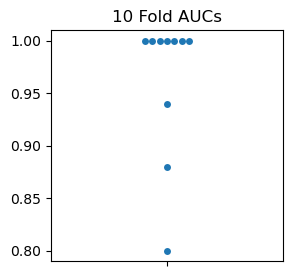

In [16]:
knn = neighbors.KNeighborsClassifier(3)
ax, fig = plt.subplots(1,1,figsize=(3,3))
cv_auc = skms.cross_val_score(knn,iris.data,iris.target==1,cv=10,scoring='roc_auc')

ax = sns.swarmplot(cv_auc,orient='v')
ax.set_title('10 Fold AUCs')

#### Multiclass Learners, One-versus-Rest, and ROC

In [17]:
checkout = [0,50,100]
print("Original Encoding")
print(iris.target[checkout])

Original Encoding
[0 1 2]


In [18]:
print("'Multi-label' Encoding")
print(skpre.label_binarize(iris.target, classes=[0,1,2])[checkout])

'Multi-label' Encoding
[[1 0 0]
 [0 1 0]
 [0 0 1]]


Text(0.5, 0, 'FPR')

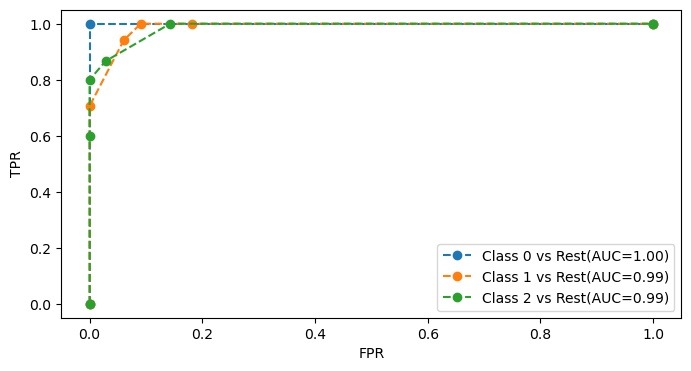

In [19]:
iris_multi_tgt = skpre.label_binarize(iris.target, classes=[0,1,2])

(im_train_ftrs,im_test_ftrs,im_train_tgt,im_test_tgt) = skms.train_test_split(iris.data,iris_multi_tgt,test_size= .33,random_state = 21)

#knn wrapped in one-versus_rest(3 classifiers)
knn  = neighbors.KNeighborsClassifier(n_neighbors = 5)
ovr_knn = skmulti.OneVsRestClassifier(knn)
preds_probs = (ovr_knn.fit(im_train_ftrs,im_train_tgt).predict_proba(im_test_ftrs))

#make roc plots
lbl_fmt = "Class {} vs Rest(AUC={:.2f})"
fig,ax = plt.subplots(figsize=(8,4))
for cls in [0,1,2]:
    fpr, tpr, _ = metrics.roc_curve(im_test_tgt[:,cls], 
                                    preds_probs[:,cls])
    label = lbl_fmt.format(cls,metrics.auc(fpr,tpr))
    ax.plot(fpr,tpr,'o--',label=label)

ax.legend()
ax.set_ylabel("TPR")
ax.set_xlabel("FPR")


#### One vs One

In [20]:
knn = neighbors.KNeighborsClassifier(n_neighbors = 5)
ovo = skmulti.OneVsOneClassifier(knn)
preds = ovo.fit(iris_train_ftrs,iris_train_tgt).decision_function(iris_test_ftrs)
df_ovo = pd.DataFrame(preds)
df_ovo['class'] = df_ovo.values.argmax(axis=1)
df_ovo.head(10)

,0,1,2,class
0,-0.2222,2.1667,1.1667,1
1,2.0000,1.0000,0.0000,0
2,2.0000,1.0000,0.0000,0
3,2.0000,1.0000,0.0000,0
4,-0.2222,2.1667,1.1667,1
5,-0.2222,2.1667,1.1667,1
6,2.0000,1.0000,0.0000,0
7,-0.2222,2.1250,1.1944,1
8,2.0000,1.0000,0.0000,0
9,2.0000,1.0000,0.0000,0


In [21]:
# note: ugly to make column headers
mi = pd.MultiIndex([['Class Indicator', 'Vote'], [0, 1, 2]],
                    [[0]*3+[1]*3,list(range(3)) * 2])
df = pd.DataFrame(np.c_[im_test_tgt, preds], 
                  columns=mi)
display(df.head())

Class Indicator                                            \
                     0                    1                    2   
0               0.0000               1.0000               0.0000   
1               1.0000               0.0000               0.0000   
2               1.0000               0.0000               0.0000   
3               1.0000               0.0000               0.0000   
4               0.0000               1.0000               0.0000   

                  Vote                                            
                     0                    1                    2  
0              -0.2222               2.1667               1.1667  
1               2.0000               1.0000               0.0000  
2               2.0000               1.0000               0.0000  
3               2.0000               1.0000               0.0000  
4              -0.2222               2.1667               1.1667

#### Precision-Recall Curve

Text(0.5, 0, 'Recall')

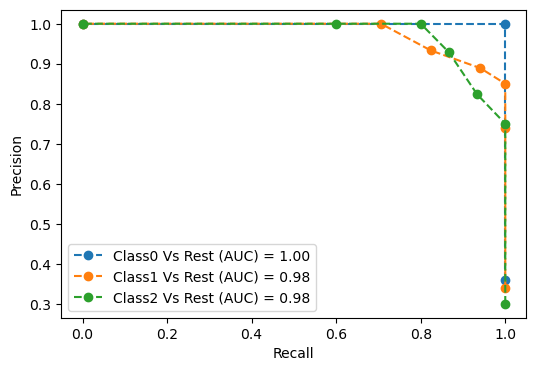

In [24]:
fig,ax = plt.subplots(figsize=(6,4))
for cls in [0,1,2]:
    prc = metrics.precision_recall_curve
    precision,recall,_ = prc(im_test_tgt[:,cls],
                            preds_probs[:,cls])
    prc_auc = metrics.auc(recall,precision)
    label = "Class{} Vs Rest (AUC) = {:.2f}".format(cls,prc_auc)
    ax.plot(recall, precision,'o--',label=label)
ax.legend()
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')

#### Cumulative response and Lift Curves

In [27]:
#negate because we want the largest values first
myorder = np.argsort(-prob_true)

#cumulative sum then to percentage(last value is total)
realpct_myorder = iris_1c_test_tgt[myorder].cumsum()
realpct_myorder = realpct_myorder/realpct_myorder[-1]

#convert counts of datas into percentages
N = iris_1c_test_tgt.size
xs = np.linspace(1/N,1,N)

print(myorder[:3])

[ 0 28 43]


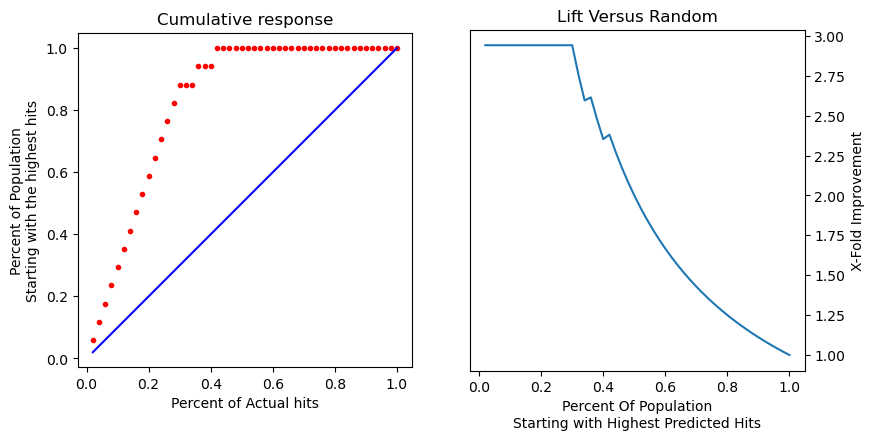

In [32]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize = (8,4))
fig.tight_layout()

#cumulative response
ax1.plot(xs,realpct_myorder,'r.')
ax1.plot(xs,xs,'b-')

ax1.set_title("Cumulative response")
ax1.axes.set_aspect('equal')

ax1.set_xlabel('Percent of Actual hits')
ax1.set_ylabel('Percent of Population\n' + 'Starting with the highest hits')

#lift
#replace divide by zero with 1.0
ax2.plot(xs,realpct_myorder/np.where(xs>0, xs ,1))



ax2.set_title("Lift Versus Random")
ax2.set_ylabel("X-Fold Improvement") # not cross-fold!
ax2.set_xlabel("Percent Of Population\n" + 
               "Starting with Highest Predicted Hits")
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right');

### 5.7 More Sophisticated Evaluation of Classifiers: Take Two

#### 1. Binary

In [45]:
#lets first choose our classifiers
classifiers = {
    'base':baseline,
    'gnb':naive_bayes.GaussianNB(),
    '3-NN':neighbors.KNeighborsClassifier(n_neighbors = 3),
    '10-NN':neighbors.KNeighborsClassifier(n_neighbors = 10)
    }

In [46]:
#define the one class iris problem
iris_onec_ftrs = iris.data
iris_onec_tgt = iris.target == 1

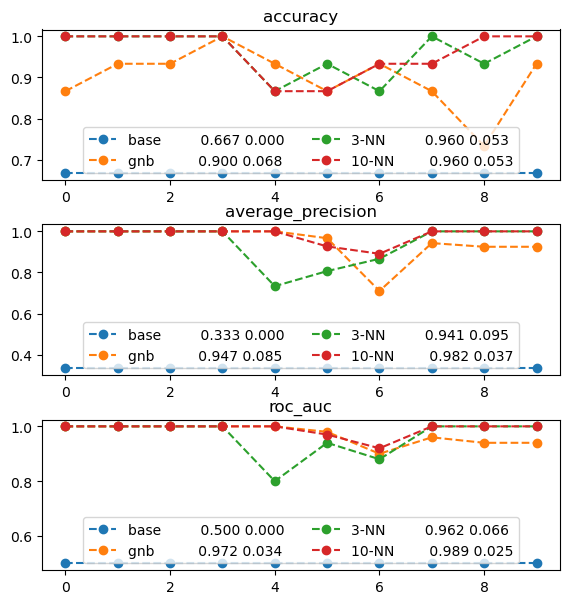

In [56]:
msrs = ['accuracy','average_precision','roc_auc']
fig, axes, = plt.subplots(len(msrs),1,figsize=(6,2*len(msrs) ))
fig.tight_layout()

for model_name, model in classifiers.items():
    cv_score = skms.cross_val_score
    cv_result  = {msr:cv_score(model,iris_onec_ftrs, iris_onec_tgt,scoring=msr,cv=10) for msr in msrs}

    for ax, msr in zip(axes,msrs):
        msr_result = cv_result[msr]
        mylabels = "{:12s} {:.3f} {:.3f}".format(model_name,msr_result.mean(),msr_result.std())
        ax.plot(msr_result,'o--',label=mylabels)
        ax.set_title(msr)
        ax.legend(loc='lower center',ncol=2)

